In [1]:
!pip install sentence-transformers

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_20newsgroups
from sentence_transformers import SentenceTransformer
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

# 1. Load the Dataset
# We select 3 specific categories to make the clustering visual and obvious
categories = ['sci.space', 'comp.graphics', 'rec.sport.hockey']
print("Loading 20 Newsgroups dataset...")

dataset = fetch_20newsgroups(subset='all',
                             categories=categories,
                             shuffle=True,
                             random_state=42,
                             remove=('headers', 'footers', 'quotes')) # Clean metadata

documents = dataset.data
labels_true = dataset.target

print(f"Loaded {len(documents)} documents.")
print(f"Example document:\n{documents[0][:200]}...")

# 2. Load SOTA Embedding Model
# 'all-MiniLM-L6-v2' is a high-speed, high-quality model ideal for clustering
print("\nLoading Sentence-Transformer model...")
model = SentenceTransformer('all-MiniLM-L6-v2')

Loading 20 Newsgroups dataset...
Loaded 2959 documents.
Example document:

    Yes.  There are many methods of rendering, raytracing is one of them.
You didn't say what you mean by rendering, so I won't guess.  Methods of
rendering include:

        o  Pencil and graph pape...

Loading Sentence-Transformer model...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/350 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

In [3]:
# 3. Generate Embeddings
# This converts our list of strings into a matrix of shape (n_samples, 384)
print("Encoding documents... (This may take a moment)")
embeddings = model.encode(documents)

print(f"Embeddings Shape: {embeddings.shape}")

# 4. Perform Clustering
# We know we have 3 categories, so we set k=3
kmeans = KMeans(n_clusters=3, random_state=42, n_init='auto')
kmeans.fit(embeddings)
labels_pred = kmeans.labels_

print("Clustering Complete.")

Encoding documents... (This may take a moment)
Embeddings Shape: (2959, 384)
Clustering Complete.


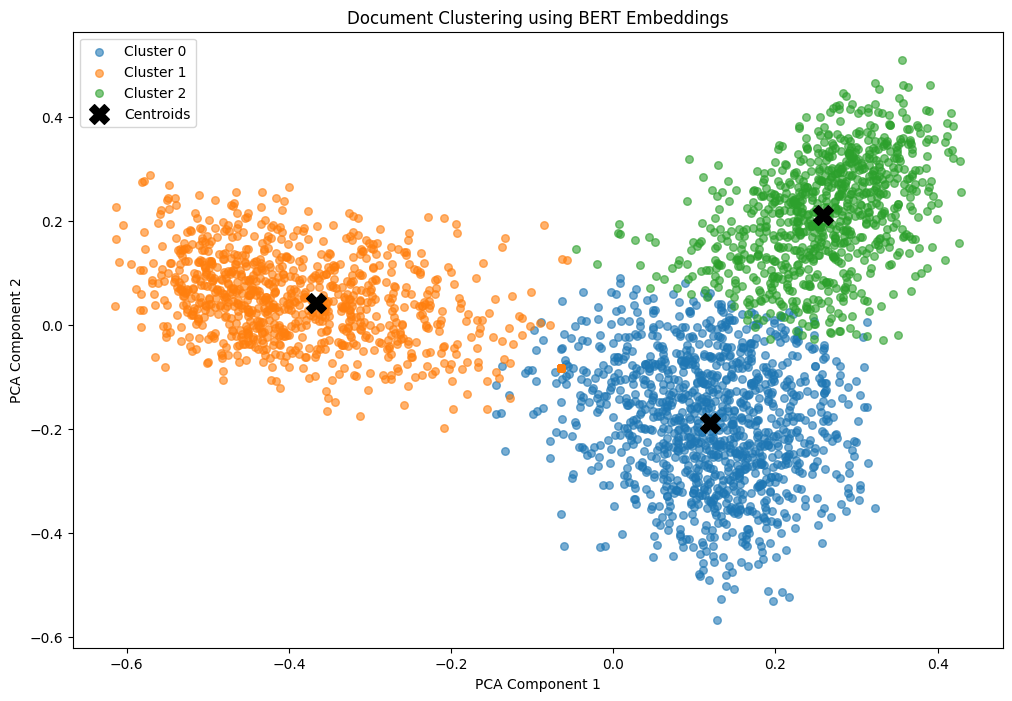


--- Cluster Analysis ---

Cluster 0 Sample Content:
 - I've borrowed the 1992-93 version of this book from a friend...holy moley!  What a wealth of contact...
 - ...  That is if Mario makes it.  Pat Walker sounds like the type that would bring an AK-47 to a game...

Cluster 1 Sample Content:
 - ...
 - Charles Hubbert writes...  Chevy has let in 2 or 3 soft goals so far, but they all didn't matter. Ho...

Cluster 2 Sample Content:
 -      Yes.  There are many methods of rendering, raytracing is one of them. You didn't say what you m...
 - I have posted disp135.zip to alt.binaries.pictures.utilities   ******   You may distribute this prog...


In [4]:
# 5. Dimensionality Reduction for Visualization
pca = PCA(n_components=2)
reduced_embeddings = pca.fit_transform(embeddings)

# 6. Plotting
plt.figure(figsize=(12, 8))
colors = ['red', 'blue', 'green']
category_names = [dataset.target_names[i] for i in range(3)]

# Plot each cluster
for i in range(3):
    # Select points belonging to this cluster
    points = reduced_embeddings[labels_pred == i]
    plt.scatter(points[:, 0], points[:, 1], s=30, alpha=0.6, label=f'Cluster {i}')

# Plot the Centroids
centroids = pca.transform(kmeans.cluster_centers_)
plt.scatter(centroids[:, 0], centroids[:, 1], marker='X', s=200, c='black', label='Centroids')

plt.title("Document Clustering using BERT Embeddings")
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.legend()
plt.show()

# 7. Print Sample Documents from each Cluster to verify
print("\n--- Cluster Analysis ---")
for i in range(3):
    print(f"\nCluster {i} Sample Content:")
    # Find indices of docs in this cluster
    indices = np.where(labels_pred == i)[0]
    # Print the first 2 docs in this cluster
    for idx in indices[:2]:
        print(f" - {documents[idx][:100].replace(chr(10), ' ')}...")